# 01 — Data Understanding & Focused Visualization

Notebook ini menggabungkan tema **Flood Prediction** dan **Rice Supply Chain Vulnerability** secara metodologis: flood dataset dipakai sebagai *hazard prediction*, rice dataset dipakai sebagai *vulnerability analysis*.

Prinsip visualisasi mengikuti referensi: setiap grafik punya fokus, threshold, density/points, heatmap, ranking, dan takeaway otomatis.

## Project framing — why these two datasets are integrated

This project does **not** merge the flood and rice supply-chain datasets row-by-row because they do not share a common geographic key, temporal key, event ID, or observed flood-disruption label. Instead, the integration follows a risk-oriented workflow:

```text
Flood dataset  → hazard signal       → FloodProbability / flood scenario
Rice dataset   → vulnerability signal → actor-region vulnerability
Stress test    → resilience signal    → survive/fail under flood stress
Decision layer → hazard × vulnerability × resilience → intervention priority
```

The five notebooks answer three business questions:

1. **Method 3 — Paper-grounded weak labeling:** Which rice supply-chain actors are financially and operationally vulnerable?
2. **Method 5 — Stress-test sensitivity analysis:** Which actor-region units collapse first when flood-related cost stress increases?
3. **Method 1 — Hazard × vulnerability decision support:** Which actor-region units should be prioritized for intervention under flood-risk scenarios?

This framing keeps the analysis methodologically safe: the flood data is treated as a hazard scenario source, while the rice supply-chain data is treated as the exposed/vulnerable system.

In [1]:
from pathlib import Path
import os, re, json, zipfile, warnings
os.environ.setdefault('OMP_NUM_THREADS','1')
os.environ.setdefault('OPENBLAS_NUM_THREADS','1')
os.environ.setdefault('MKL_NUM_THREADS','1')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 140)
pd.set_option('display.width', 160)
PROJECT_ROOT = Path.cwd()
DATA_RAW = PROJECT_ROOT / 'data' / 'raw'
OUTPUT_DIR = PROJECT_ROOT / 'outputs'
FIG_DIR = PROJECT_ROOT / 'figures'
MODEL_DIR = PROJECT_ROOT / 'models'
DATA_EXTERNAL = PROJECT_ROOT / 'data' / 'external'
for p in [DATA_RAW, DATA_EXTERNAL, OUTPUT_DIR, FIG_DIR, MODEL_DIR]: p.mkdir(parents=True, exist_ok=True)
plt.rcParams.update({'figure.dpi':130,'savefig.dpi':180,'font.size':10,'axes.titlesize':13,'axes.labelsize':10,'axes.spines.top':False,'axes.spines.right':False,'axes.grid':True,'grid.alpha':0.22,'legend.frameon':False})
COLORS={'navy':'#243B53','blue':'#2F80ED','sky':'#9CC9F5','orange':'#F2994A','red':'#D64545','green':'#27AE60','gray':'#6B7280','purple':'#7B61FF','teal':'#2D9CDB'}
def savefig(name):
    path=FIG_DIR/name; plt.tight_layout(); plt.savefig(path,bbox_inches='tight'); print('saved:', path)
def robust_minmax(s, qlo=0.01, qhi=0.99):
    s=pd.to_numeric(s,errors='coerce').astype(float); lo=s.quantile(qlo); hi=s.quantile(qhi)
    if pd.isna(lo) or pd.isna(hi) or hi==lo: return pd.Series(0.5,index=s.index)
    return ((s.clip(lo,hi)-lo)/(hi-lo)).clip(0,1)
def safe_div(a,b): return pd.to_numeric(a,errors='coerce')/pd.to_numeric(b,errors='coerce').replace(0,np.nan)
def safe_sum(df, cols):
    cols=[c for c in cols if c in df.columns]
    return df[cols].sum(axis=1, skipna=True) if cols else pd.Series(np.nan,index=df.index)


TARGET_FLOOD='FloodProbability'
FLOOD_FEATURE_GROUPS={
 'Climate & natural pressure':['MonsoonIntensity','ClimateChange','TopographyDrainage','CoastalVulnerability','Landslides','Watersheds','WetlandLoss'],
 'Land-use pressure':['Deforestation','Urbanization','AgriculturalPractices','Encroachments','PopulationScore'],
 'Hydraulic infrastructure':['RiverManagement','DrainageSystems','Siltation','DamsQuality','DeterioratingInfrastructure'],
 'Governance & preparedness':['IneffectiveDisasterPreparedness','InadequatePlanning','PoliticalFactors']
}
ACTOR_CONFIG={
 'Farmer':{'cost_cols':['land_lease_value_idr','labor_cost_idr','seed_purchase_value_idr','fertilizer_purchase_value_idr','pesticide_purchase_value_idr','equipment_rent_value_idr'],'output_cols':['production_value_idr'],'quantity_cols':['land_area_m2'],'role':'upstream production'},
 'Rice Miller':{'cost_cols':['value_of_milled_grains_idr','labor_cost_idr','supporting_equipment_cost_idr'],'output_cols':['nilaiberashasilgiling','total_revenue_of_milling_machine_idr'],'quantity_cols':['amount_of_milled_rice_kg','number_of_machines_unit'],'role':'processing capacity'},
 'Middlemen':{'cost_cols':['total_rice_purchase_idr','building_rent_cost_idr','labor_cost_idr','supporting_equipment_cost_idr'],'output_cols':['value_of_rice_sold_idr'],'quantity_cols':['total_rice_purchase_kg'],'precip_cols':['total_precipitation_pct','precipitation_quality_pct'],'role':'aggregation and trading'},
 'Wholesaler':{'cost_cols':['value_of_rice_purchase_idr','building_rent_cost_idr','labor_cost_idr','supporting_equipment_cost_idr'],'output_cols':['value_of_rice_sold_idr'],'precip_cols':['precipitation_quality_pct'],'role':'bulk distribution'},
 'Retail':{'cost_cols':['value_of_rice_purchase_idr','building_rent_cost_idr','labor_cost_idr','supporting_equipment_cost_idr'],'output_cols':['value_of_rice_sold_idr'],'precip_cols':['precipitation_quality_pct'],'role':'consumer-facing distribution'}
}


def find_file(names):
    roots=[PROJECT_ROOT, PROJECT_ROOT/'input', PROJECT_ROOT/'data', DATA_RAW, Path('/mnt/data'), Path('/kaggle/input')]
    hits=[]
    for root in roots:
        if root.exists():
            for name in names: hits += list(root.rglob(name))
    hits=[p for p in hits if p.is_file()]
    if not hits: raise FileNotFoundError(f'File tidak ditemukan: {names}. Letakkan ZIP dataset di folder notebook/data/raw.')
    return sorted(hits, key=lambda p: len(str(p)))[0]

def slugify(x):
    raw=str(x).strip().lower(); has_idr='idr' in raw; has_kg='kg' in raw; has_m2='m2' in raw; has_pct='%' in raw or 'percent' in raw
    base=re.sub(r'\([^)]*\)','',raw); base=base.replace('%',' pct '); base=re.sub(r'[^a-z0-9]+','_',base).strip('_')
    if has_idr and not base.endswith('_idr'): base += '_idr'
    if has_kg and not base.endswith('_kg'): base += '_kg'
    if has_m2 and not base.endswith('_m2'): base += '_m2'
    if has_pct and not base.endswith('_pct'): base += '_pct'
    return base

def parse_actor_sheet(path, sheet):
    raw=pd.read_excel(path, sheet_name=sheet, header=None); actor=sheet.replace(' Data','').strip(); records=[]; audit=[]; region=None; header=None
    for idx,row in raw.iterrows():
        vals=row.tolist(); non=[v for v in vals if not pd.isna(v)]
        if not non: continue
        first=str(vals[0]).strip() if not pd.isna(vals[0]) else ''; rest_empty=all(pd.isna(v) for v in vals[1:])
        if rest_empty and first and first.lower()!='dmu': region=first; header=None; continue
        if first.lower()=='dmu':
            header=[slugify(v) for v in vals if not pd.isna(v)]; audit.append({'actor':actor,'region':region,'header_row':idx,'n_cols':len(header)}); continue
        if region and header:
            rec=dict(zip(header, vals[:len(header)]))
            if pd.isna(rec.get('dmu')): continue
            rec.update({'actor':actor,'region':region,'source_sheet':sheet,'source_row':int(idx)}); records.append(rec)
    return pd.DataFrame(records), pd.DataFrame(audit)

def load_raw_datasets():
    flood_zip=find_file(['Flood Prediction.zip','flood-prediction.zip'])
    rice_zip=find_file(['Rice Supply Chain in West Java Province, Indonesia.zip','Rice Supply Chain in West Java Province, Indonesia(1).zip'])
    for z in [flood_zip, rice_zip]:
        with zipfile.ZipFile(z) as zz: zz.extractall(DATA_RAW)
        print('extracted:', z.name)
    flood_path=list(DATA_RAW.rglob('flood.csv'))[0]
    rice_path=list(DATA_RAW.rglob('Rice Supply Chain in West Java Province, Indonesia.xlsx'))[0]
    flood=pd.read_csv(flood_path)
    xl=pd.ExcelFile(rice_path)
    frames=[]; audits=[]
    for sheet in xl.sheet_names:
        a,b=parse_actor_sheet(rice_path,sheet); frames.append(a); audits.append(b)
    rice=pd.concat(frames, ignore_index=True, sort=False); audit=pd.concat(audits, ignore_index=True, sort=False)
    front=['actor','region','dmu','source_sheet','source_row']; rice=rice[[c for c in front if c in rice]+[c for c in rice.columns if c not in front]]
    for c in rice.columns:
        if c not in ['actor','region','source_sheet']: rice[c]=pd.to_numeric(rice[c], errors='coerce')
    return flood, rice, audit

def engineer_rice_base(rice):
    df=rice.copy()
    for col in ['total_cost','output_value','operational_cost','quantity_proxy','precipitation_stress_raw','actor_role']: df[col]=np.nan
    for actor,cfg in ACTOR_CONFIG.items():
        m=df['actor'].eq(actor); cost=cfg.get('cost_cols',[]); out=cfg.get('output_cols',[]); qty=cfg.get('quantity_cols',[]); precip=cfg.get('precip_cols',[])
        df.loc[m,'total_cost']=safe_sum(df.loc[m], cost); df.loc[m,'output_value']=safe_sum(df.loc[m], out)
        purchase_like=[c for c in cost if any(k in c for k in ['purchase','milled_grains'])]
        df.loc[m,'operational_cost']=safe_sum(df.loc[m], [c for c in cost if c not in purchase_like])
        if qty: df.loc[m,'quantity_proxy']=safe_sum(df.loc[m], qty)
        if precip:
            tmp=df.loc[m,[c for c in precip if c in df.columns]].copy()
            for pc in tmp.columns:
                if pd.to_numeric(tmp[pc],errors='coerce').max() <= 1: tmp[pc]=tmp[pc]*100
            if tmp.shape[1]>0: df.loc[m,'precipitation_stress_raw']=tmp.mean(axis=1)
        df.loc[m,'actor_role']=cfg.get('role')
    df['margin']=df['output_value']-df['total_cost']; df['rc_ratio']=safe_div(df['output_value'],df['total_cost']); df['cost_revenue_ratio']=safe_div(df['total_cost'],df['output_value']); df['margin_ratio']=safe_div(df['margin'],df['output_value']); df['operational_burden_ratio']=safe_div(df['operational_cost'],df['output_value']); df['cost_per_quantity_proxy']=safe_div(df['total_cost'],df['quantity_proxy']); df['output_per_quantity_proxy']=safe_div(df['output_value'],df['quantity_proxy']); df['negative_margin_flag']=(df['margin']<0).astype(int); df['below_break_even_flag']=(df['rc_ratio']<1).astype(int)
    return df

## Notebook map and expected handoff files

| Notebook | Main question | Main outputs |
|---|---|---|
| 01 | What information is available in both datasets? | `01_flood_raw.csv`, `01_rice_consolidated_raw.csv`, EDA figures |
| 02 | Which rice supply-chain units are vulnerable? | `02_rice_vulnerability_dataset.csv`, `02_method3_labeling_functions.csv` |
| 03 | Which models best learn flood probability and rice vulnerability? | `03_flood_full_predictions.csv`, `03_rice_full_predictions.csv`, `03_actor_region_model_summary.csv` |
| 04 | Which actor-region units fail under stress scenarios? | `04_unit_stress_test_results.csv`, `04_actor_region_stress_summary.csv` |
| 05 | Which actor-region units should be prioritized? | `05_final_flood_logistics_priority.csv`, `05_high_priority_shortlist.csv` |

## 1. Load and parse datasets

Tidak ada dataset eksternal. File ZIP dibaca dari folder notebook / `data/raw` / `/mnt/data`.

In [2]:
flood_df, rice_raw, parser_audit = load_raw_datasets()
rice_understanding = engineer_rice_base(rice_raw)
print('Flood shape:', flood_df.shape)
print('Rice long shape:', rice_raw.shape)
display(flood_df.head())
display(rice_understanding[['actor','region','dmu','total_cost','output_value','margin','rc_ratio']].head())

extracted: Flood Prediction.zip
extracted: Rice Supply Chain in West Java Province, Indonesia.zip
Flood shape: (50000, 21)
Rice long shape: (787, 26)


,MonsoonIntensity,TopographyDrainage,RiverManagement,Deforestation,Urbanization,ClimateChange,DamsQuality,Siltation,AgriculturalPractices,Encroachments,IneffectiveDisasterPreparedness,DrainageSystems,CoastalVulnerability,Landslides,Watersheds,DeterioratingInfrastructure,PopulationScore,WetlandLoss,InadequatePlanning,PoliticalFactors,FloodProbability
0,3,8,6,6,4,4,6,2,3,2,5,10,7,4,2,3,4,3,2,6,0.450
1,8,4,5,7,7,9,1,5,5,4,6,9,2,6,2,1,1,9,1,3,0.475
2,3,10,4,1,7,5,4,7,4,9,2,7,4,4,8,6,1,8,3,6,0.515
3,4,4,2,7,3,4,1,4,6,4,9,4,2,6,6,8,8,6,6,10,0.520
4,3,7,5,2,5,8,5,2,7,5,7,7,6,5,3,3,4,4,3,4,0.475


,actor,region,dmu,total_cost,output_value,margin,rc_ratio
0,Farmer,Garut,1,11418000.0,16200000.0,4782000.0,1.418812
1,Farmer,Garut,2,8264000.0,8100000.0,-164000.0,0.980155
2,Farmer,Garut,3,6450000.0,14850000.0,8400000.0,2.302326
3,Farmer,Garut,4,4570000.0,13050000.0,8480000.0,2.855580
4,Farmer,Garut,5,3778000.0,10200000.0,6422000.0,2.699841


## 2. Dataset audit and feature dictionary

In [3]:
feature_rows=[]
for g,cols in FLOOD_FEATURE_GROUPS.items():
    for c in cols: feature_rows.append({'dataset':'Flood','feature':c,'group':g,'usage':'hazard predictor'})
feature_rows.append({'dataset':'Flood','feature':TARGET_FLOOD,'group':'Target','usage':'regression target'})
for actor,cfg in ACTOR_CONFIG.items():
    for c in cfg.get('cost_cols',[]): feature_rows.append({'dataset':'Rice','feature':c,'group':actor,'usage':'cost/input'})
    for c in cfg.get('output_cols',[]): feature_rows.append({'dataset':'Rice','feature':c,'group':actor,'usage':'output/revenue'})
    for c in cfg.get('quantity_cols',[]): feature_rows.append({'dataset':'Rice','feature':c,'group':actor,'usage':'quantity/capacity'})
    for c in cfg.get('precip_cols',[]): feature_rows.append({'dataset':'Rice','feature':c,'group':actor,'usage':'environmental proxy'})
feature_dictionary=pd.DataFrame(feature_rows).drop_duplicates()
audit=pd.DataFrame([{'dataset':'Flood','rows':len(flood_df),'cols':flood_df.shape[1],'missing':int(flood_df.isna().sum().sum()),'target_or_focus':'FloodProbability'}, {'dataset':'Rice','rows':len(rice_raw),'cols':rice_raw.shape[1],'missing':int(rice_raw.isna().sum().sum()),'target_or_focus':'no target; vulnerability indicators'}])
display(audit); display(feature_dictionary.head(20)); display(parser_audit)

,dataset,rows,cols,missing,target_or_focus
0,Flood,50000,21,0,FloodProbability
1,Rice,787,26,10692,no target; vulnerability indicators


,dataset,feature,group,usage
0,Flood,MonsoonIntensity,Climate & natural pressure,hazard predictor
1,Flood,ClimateChange,Climate & natural pressure,hazard predictor
2,Flood,TopographyDrainage,Climate & natural pressure,hazard predictor
3,Flood,CoastalVulnerability,Climate & natural pressure,hazard predictor
4,Flood,Landslides,Climate & natural pressure,hazard predictor
5,Flood,Watersheds,Climate & natural pressure,hazard predictor
6,Flood,WetlandLoss,Climate & natural pressure,hazard predictor
7,Flood,Deforestation,Land-use pressure,hazard predictor
8,Flood,Urbanization,Land-use pressure,hazard predictor
9,Flood,AgriculturalPractices,Land-use pressure,hazard predictor


,actor,region,header_row,n_cols
0,Farmer,Garut,1,9
1,Farmer,Indramayu,102,9
2,Farmer,Karawang,167,9
3,Farmer,Subang,223,9
4,Farmer,Tasikmalaya,303,9
5,Rice Miller,Garut,1,8
6,Rice Miller,Indramayu,28,8
7,Rice Miller,Karawang,48,8
8,Rice Miller,Subang,65,8
9,Rice Miller,Tasikmalaya,89,8


## 3. Flood visual — target distribution with high-risk focus

Fokus: melihat porsi observasi di atas kuartil atas `FloodProbability`.

saved: c:\Users\USER\Documents\VSCODE\flood_rice_resilience_project\figures\01_flood_target_distribution.png


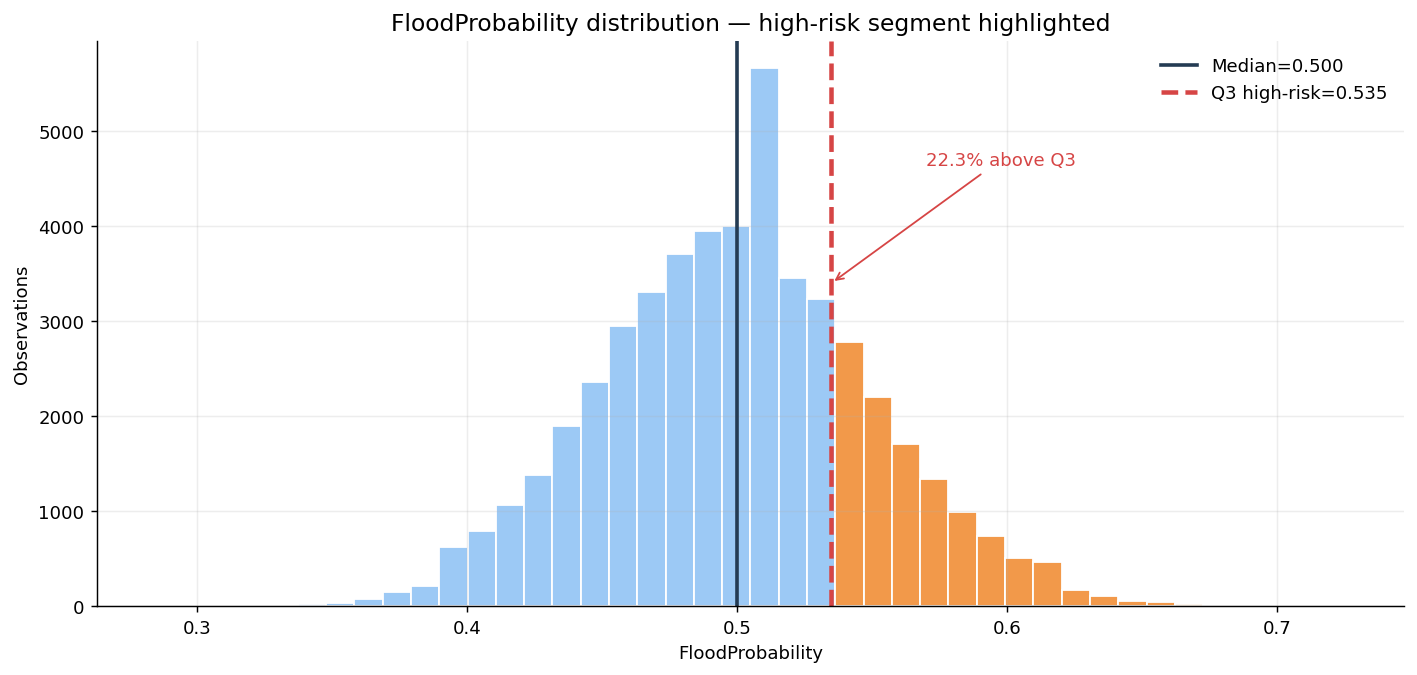

In [4]:
target=flood_df[TARGET_FLOOD]; q1,med,q3=target.quantile([.25,.5,.75]); high_share=(target>q3).mean()*100
fig,ax=plt.subplots(figsize=(11,5.3)); counts,bins,patches=ax.hist(target,bins=42,color=COLORS['sky'],edgecolor='white')
for patch,left in zip(patches,bins[:-1]):
    if left>=q3: patch.set_facecolor(COLORS['orange'])
ax.axvline(med,color=COLORS['navy'],lw=2,label=f'Median={med:.3f}'); ax.axvline(q3,color=COLORS['red'],lw=2.5,ls='--',label=f'Q3 high-risk={q3:.3f}')
ax.annotate(f'{high_share:.1f}% above Q3',xy=(q3,counts.max()*.6),xytext=(q3+.035,counts.max()*.82),arrowprops=dict(arrowstyle='->',color=COLORS['red']),color=COLORS['red']); ax.set_title('FloodProbability distribution — high-risk segment highlighted'); ax.set_xlabel('FloodProbability'); ax.set_ylabel('Observations'); ax.legend(); savefig('01_flood_target_distribution.png'); plt.show()

## 4. Flood visual — grouped pressure trend

Fokus: apakah skor tekanan gabungan naik searah dengan probabilitas banjir.

saved: c:\Users\USER\Documents\VSCODE\flood_rice_resilience_project\figures\01_flood_pressure_trend.png


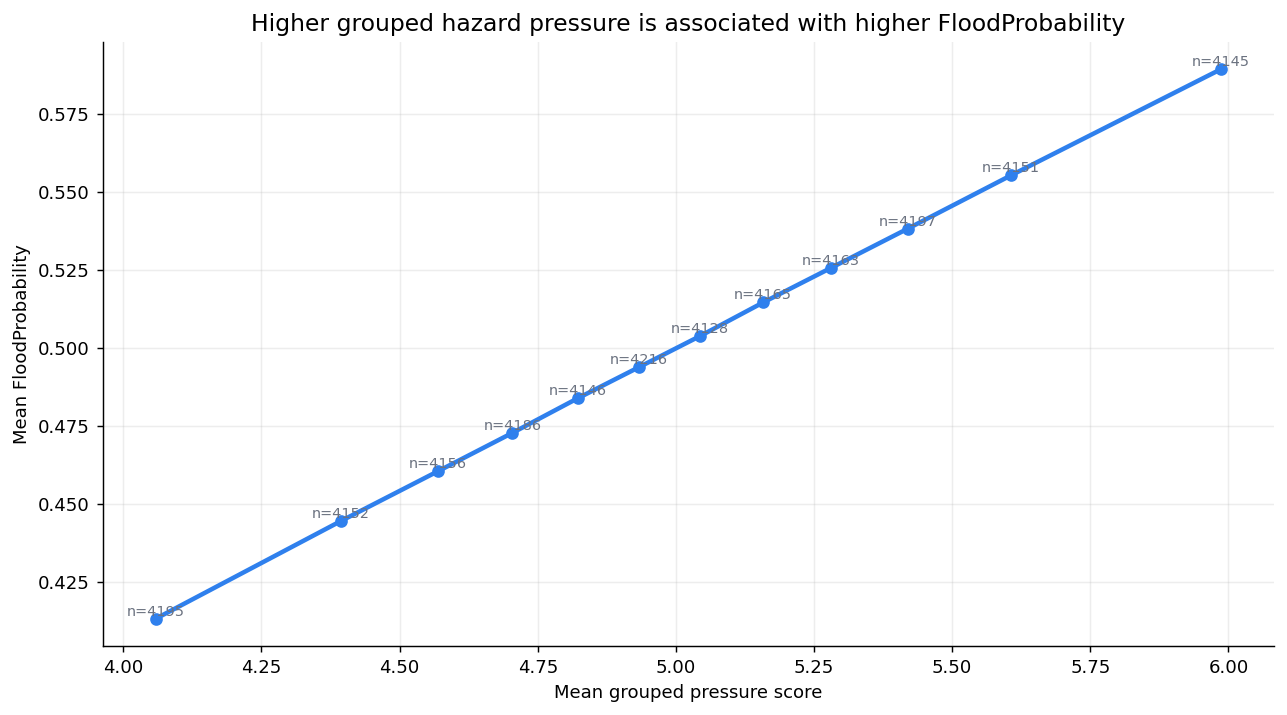

In [5]:
flood_grouped=flood_df.copy()
for g,cols in FLOOD_FEATURE_GROUPS.items(): flood_grouped[g]=flood_grouped[cols].mean(axis=1)
flood_grouped['total_pressure_score']=flood_grouped[list(FLOOD_FEATURE_GROUPS.keys())].mean(axis=1)
flood_grouped['pressure_bin']=pd.qcut(flood_grouped['total_pressure_score'],q=12,duplicates='drop')
trend=flood_grouped.groupby('pressure_bin',observed=True).agg(mean_pressure=('total_pressure_score','mean'),mean_flood=(TARGET_FLOOD,'mean'),n=(TARGET_FLOOD,'size')).reset_index(drop=True)
fig,ax=plt.subplots(figsize=(10,5.6)); ax.plot(trend['mean_pressure'],trend['mean_flood'],marker='o',color=COLORS['blue'],lw=2.5)
for _,r in trend.iterrows(): ax.text(r['mean_pressure'],r['mean_flood']+.001,f"n={int(r['n'])}",ha='center',fontsize=8,color=COLORS['gray'])
ax.set_title('Higher grouped hazard pressure is associated with higher FloodProbability'); ax.set_xlabel('Mean grouped pressure score'); ax.set_ylabel('Mean FloodProbability'); savefig('01_flood_pressure_trend.png'); plt.show()

## 5. Rice visual — actor-region coverage heatmap

saved: c:\Users\USER\Documents\VSCODE\flood_rice_resilience_project\figures\01_rice_coverage_heatmap.png


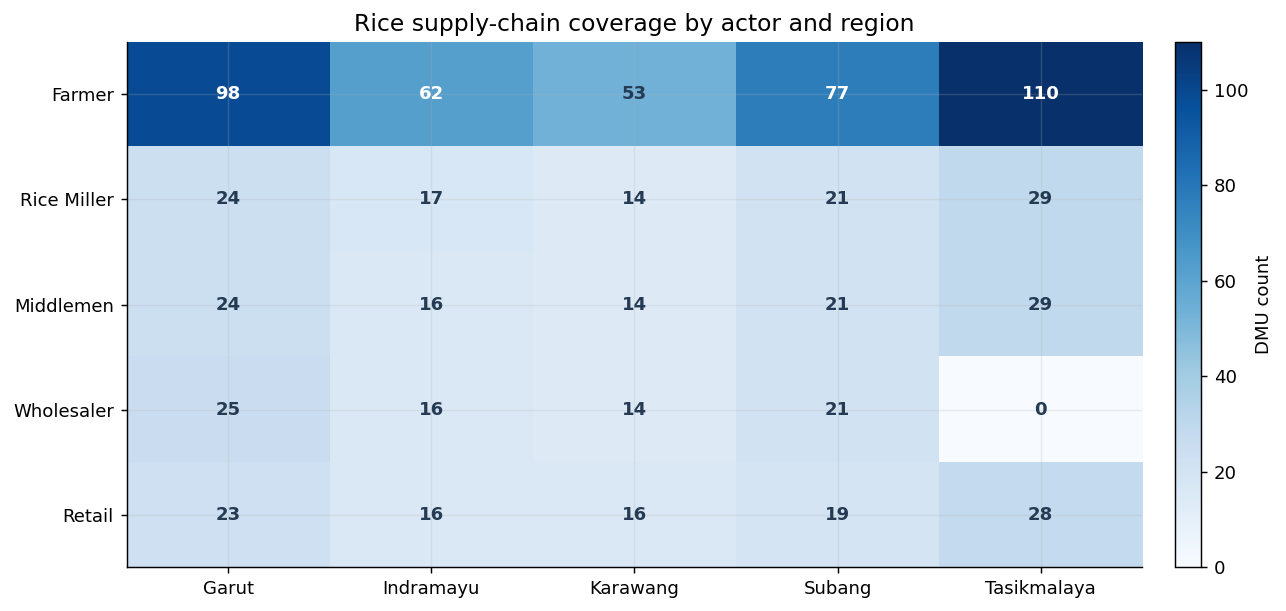

In [6]:
coverage=rice_understanding.pivot_table(index='actor',columns='region',values='dmu',aggfunc='count',fill_value=0).reindex([a for a in ACTOR_CONFIG if a in rice_understanding['actor'].unique()])
fig,ax=plt.subplots(figsize=(10,4.8)); im=ax.imshow(coverage.values,aspect='auto',cmap='Blues'); ax.set_xticks(np.arange(coverage.shape[1])); ax.set_xticklabels(coverage.columns); ax.set_yticks(np.arange(coverage.shape[0])); ax.set_yticklabels(coverage.index); ax.set_title('Rice supply-chain coverage by actor and region')
for i in range(coverage.shape[0]):
    for j in range(coverage.shape[1]): ax.text(j,i,int(coverage.iloc[i,j]),ha='center',va='center',color='white' if coverage.iloc[i,j]>coverage.values.max()*.55 else COLORS['navy'],fontweight='bold')
plt.colorbar(im,ax=ax,fraction=.035,pad=.03).set_label('DMU count'); savefig('01_rice_coverage_heatmap.png'); plt.show()

## 6. Rice visual — density + points on R/C ratio

Fokus: garis `R/C = 1` menunjukkan break-even. Titik merah adalah DMU yang berada di bawah break-even.

saved: c:\Users\USER\Documents\VSCODE\flood_rice_resilience_project\figures\01_rice_rc_density_points.png


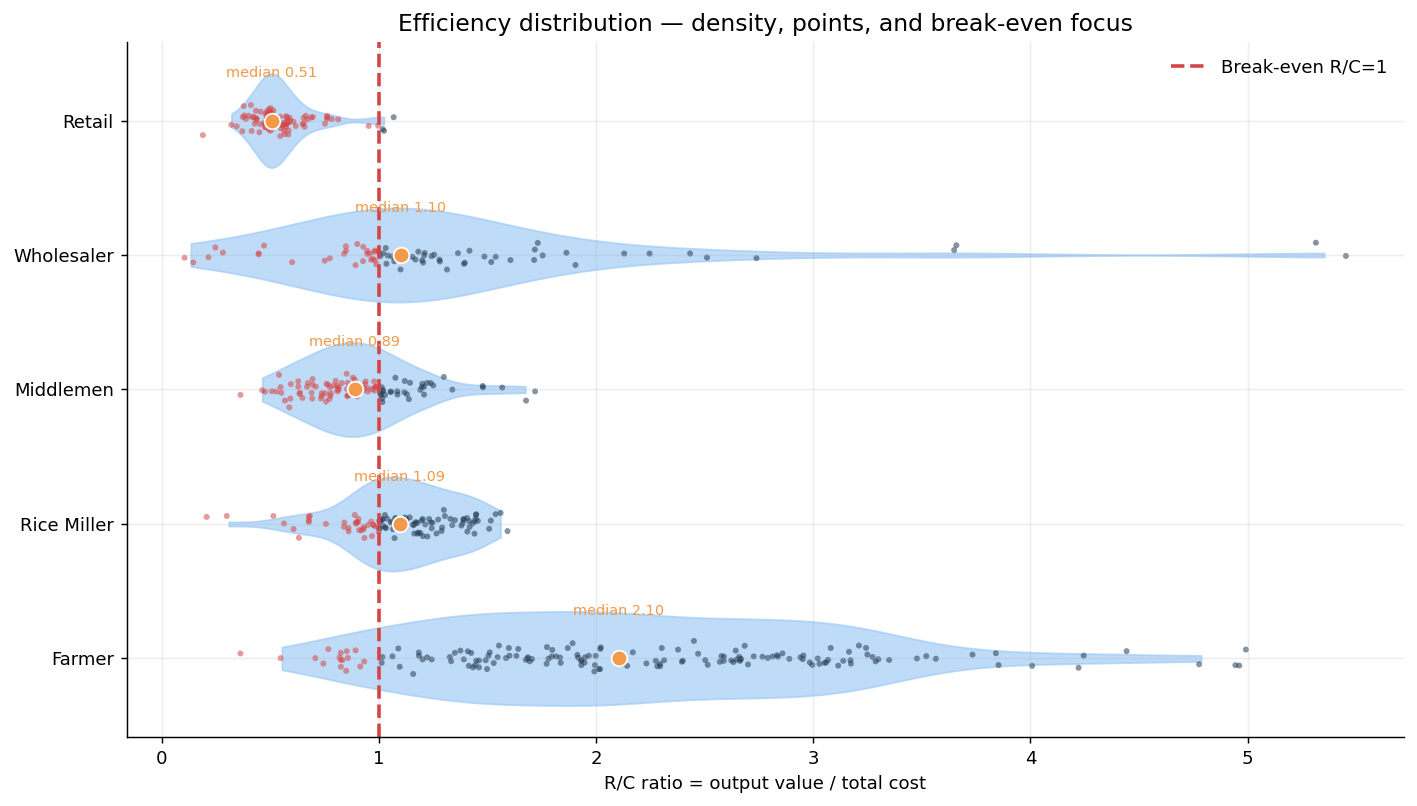

In [7]:
actors=[a for a in ACTOR_CONFIG if a in rice_understanding['actor'].unique()]
plot_df=rice_understanding.replace([np.inf,-np.inf],np.nan).dropna(subset=['rc_ratio']); plot_df=plot_df[(plot_df['rc_ratio']>0)&(plot_df['rc_ratio']<plot_df['rc_ratio'].quantile(.99))]
fig,ax=plt.subplots(figsize=(11,6.3)); rng=np.random.default_rng(42)
for yi,actor in enumerate(actors):
    vals=plot_df.loc[plot_df['actor'].eq(actor),'rc_ratio'].dropna().values
    if len(vals)<3: continue
    xgrid=np.linspace(max(0,np.percentile(vals,1)),np.percentile(vals,99),240); bw=max(np.std(vals)*(len(vals)**(-1/5)),1e-3); dens=np.exp(-.5*((xgrid[:,None]-vals[None,:])/bw)**2).sum(axis=1)/(len(vals)*bw*np.sqrt(2*np.pi)); dens=dens/dens.max()*.35
    ax.fill_between(xgrid,yi-dens,yi+dens,color=COLORS['sky'],alpha=.65)
    sample=vals if len(vals)<=160 else rng.choice(vals,160,replace=False); jitter=rng.normal(0,.045,len(sample)); ax.scatter(sample,yi+jitter,s=11,c=np.where(sample<1,COLORS['red'],COLORS['navy']),alpha=.55,lw=0)
    med=np.median(vals); ax.scatter([med],[yi],s=75,color=COLORS['orange'],edgecolor='white',zorder=5); ax.text(med,yi+.32,f'median {med:.2f}',ha='center',fontsize=8,color=COLORS['orange'])
ax.axvline(1,color=COLORS['red'],ls='--',lw=2,label='Break-even R/C=1'); ax.set_yticks(range(len(actors))); ax.set_yticklabels(actors); ax.set_xlabel('R/C ratio = output value / total cost'); ax.set_title('Efficiency distribution — density, points, and break-even focus'); ax.legend(); savefig('01_rice_rc_density_points.png'); plt.show()

## 7. Rice visual — vulnerable share and regional R/C heatmap

saved: c:\Users\USER\Documents\VSCODE\flood_rice_resilience_project\figures\01_rice_vulnerable_share_actor.png


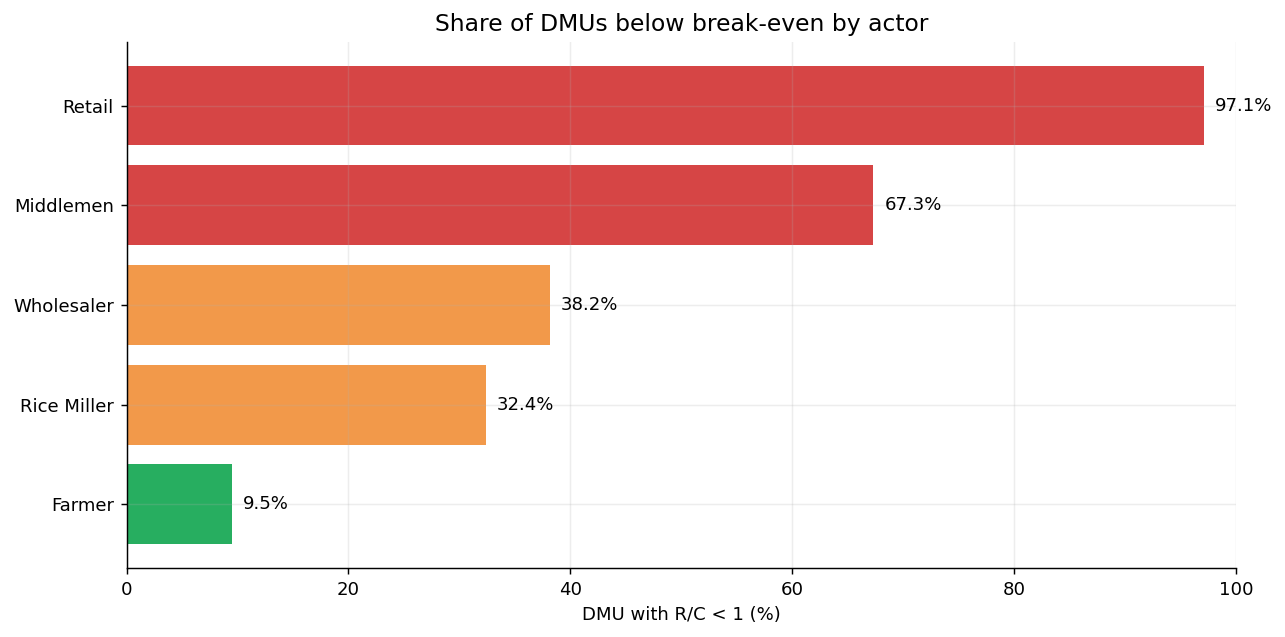

saved: c:\Users\USER\Documents\VSCODE\flood_rice_resilience_project\figures\01_rice_regional_rc_heatmap.png


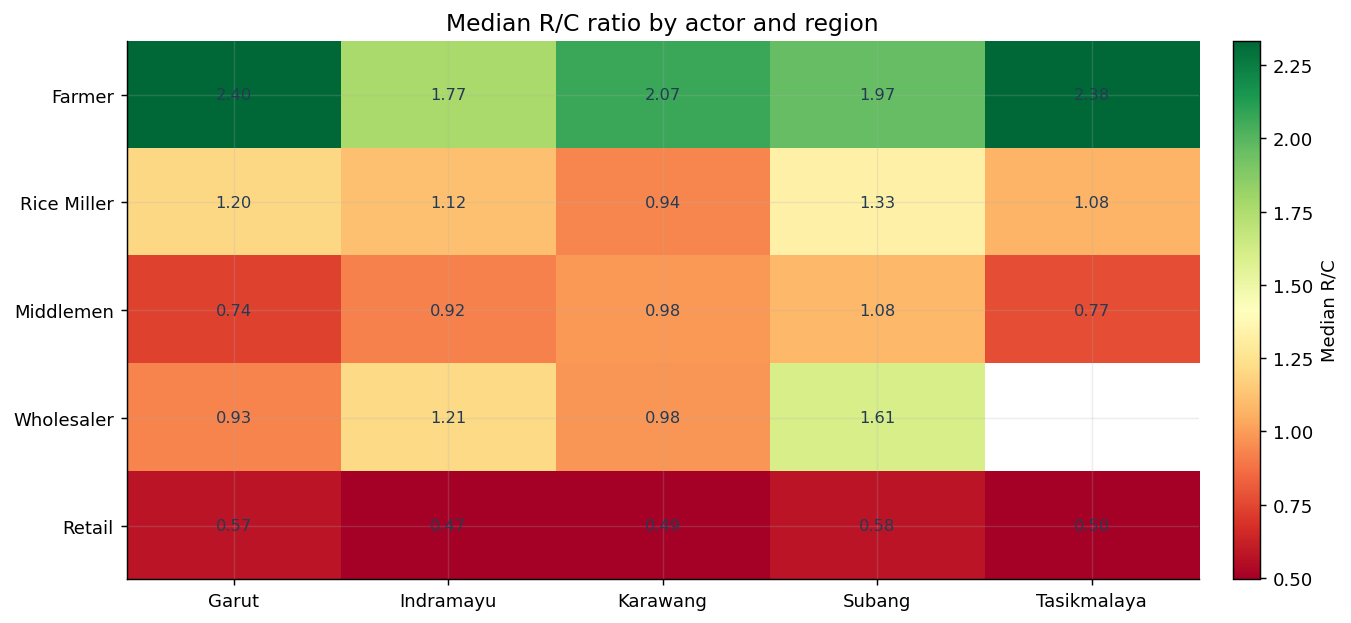

In [8]:
summary=rice_understanding.groupby(['actor','region'],as_index=False).agg(n_dmu=('dmu','count'),median_cost=('total_cost','median'),median_output=('output_value','median'),median_margin=('margin','median'),median_rc=('rc_ratio','median'),vulnerable_share=('rc_ratio',lambda s:np.mean(s<1)*100))
vuln=rice_understanding.groupby('actor')['rc_ratio'].apply(lambda s:np.mean(s<1)*100).reindex(actors).sort_values()
fig,ax=plt.subplots(figsize=(10,5)); bars=ax.barh(vuln.index,vuln.values,color=[COLORS['green'] if v<25 else COLORS['orange'] if v<60 else COLORS['red'] for v in vuln.values]); ax.set_xlim(0,100); ax.set_xlabel('DMU with R/C < 1 (%)'); ax.set_title('Share of DMUs below break-even by actor')
for b,v in zip(bars,vuln.values): ax.text(v+1,b.get_y()+b.get_height()/2,f'{v:.1f}%',va='center')
savefig('01_rice_vulnerable_share_actor.png'); plt.show()
heat=summary.pivot(index='actor',columns='region',values='median_rc').reindex(actors); fig,ax=plt.subplots(figsize=(10.5,4.9)); im=ax.imshow(heat.values,aspect='auto',cmap='RdYlGn',vmin=np.nanpercentile(heat.values,5),vmax=np.nanpercentile(heat.values,95)); ax.set_xticks(np.arange(heat.shape[1])); ax.set_xticklabels(heat.columns); ax.set_yticks(np.arange(heat.shape[0])); ax.set_yticklabels(heat.index); ax.set_title('Median R/C ratio by actor and region')
for i in range(heat.shape[0]):
    for j in range(heat.shape[1]):
        if pd.notna(heat.iloc[i,j]): ax.text(j,i,f'{heat.iloc[i,j]:.2f}',ha='center',va='center',fontsize=9,color=COLORS['navy'])
plt.colorbar(im,ax=ax,fraction=.035,pad=.03).set_label('Median R/C'); savefig('01_rice_regional_rc_heatmap.png'); plt.show()

## 8. Save Notebook 01 outputs

In [9]:
flood_df.to_csv(OUTPUT_DIR/'01_flood_raw.csv',index=False); rice_raw.to_csv(OUTPUT_DIR/'01_rice_consolidated_raw.csv',index=False); rice_understanding.to_csv(OUTPUT_DIR/'01_rice_understanding.csv',index=False); summary.to_csv(OUTPUT_DIR/'01_rice_summary_by_actor_region.csv',index=False); parser_audit.to_csv(OUTPUT_DIR/'01_parser_audit.csv',index=False); feature_dictionary.to_csv(OUTPUT_DIR/'01_feature_dictionary.csv',index=False)
context={'target_flood':TARGET_FLOOD,'flood_feature_groups':FLOOD_FEATURE_GROUPS,'actor_config':ACTOR_CONFIG,'integration_note':'Two datasets are integrated at analytical/scenario level, not row-wise merge, because no shared key exists.'}
json.dump(context,open(OUTPUT_DIR/'01_project_context.json','w'),indent=2)
print('Saved:', sorted(p.name for p in OUTPUT_DIR.glob('01_*')))

Saved: ['01_feature_dictionary.csv', '01_flood_raw.csv', '01_parser_audit.csv', '01_project_context.json', '01_rice_consolidated_raw.csv', '01_rice_summary_by_actor_region.csv', '01_rice_understanding.csv']


## 7. External regional flood exposure bridge — Open Data Jabar

This section adds a small **regional bridge** between the rice supply-chain regions and historical flood occurrence context in West Java.

Source: Open Data Jabar, **Jumlah Kejadian Bencana Banjir Berdasarkan Kabupaten/Kota di Jawa Barat**. For this project, the CSV is manually filtered to the 5 rice regions only: Garut, Indramayu, Karawang, Subang, and Tasikmalaya for 2012–2025.

Important methodological rule:

```text
Open Data Jabar flood events = regional historical exposure bridge only
It does not replace the primary Flood Prediction dataset
It is not used to train the primary FloodProbability model
It becomes a capped modifier in Notebook 04 and 05
```

Implementation detail: downstream joins use `region_key` so title-case and uppercase region names cannot break the external bridge merge.

Jabar source used: jabar_flood_events_by_kabupaten_kota.csv
Rows in external file: 70
Rows after filtering 5 rice regions: 70
Observed years by region:


,region_key,years_observed
0,GARUT,14
1,INDRAMAYU,14
2,KARAWANG,14
3,SUBANG,14
4,TASIKMALAYA,14


,region,region_key,flood_events_total,flood_events_total_2012_2025,flood_events_mean_annual,flood_events_recent_5y,flood_events_max_yearly,flood_events_trend_slope,years_observed,latest_year,historical_flood_exposure_score,historical_flood_exposure_level,external_data_coverage,source_dataset,source_url,source_file_used,methodological_role
2,Karawang,KARAWANG,225,225,16.071429,118,71,0.767033,14,2025,1.000000,High,multi-year,Open Data Jabar - jumlah kejadian bencana banj...,https://opendata.jabarprov.go.id/id/dataset/ju...,jabar_flood_events_by_kabupaten_kota.csv,regional exposure bridge only; not used to tra...
0,Garut,GARUT,141,141,10.071429,55,21,0.318681,14,2025,0.394955,Medium,multi-year,Open Data Jabar - jumlah kejadian bencana banj...,https://opendata.jabarprov.go.id/id/dataset/ju...,jabar_flood_events_by_kabupaten_kota.csv,regional exposure bridge only; not used to tra...
3,Subang,SUBANG,113,113,8.071429,51,39,-0.076923,14,2025,0.364147,Medium,multi-year,Open Data Jabar - jumlah kejadian bencana banj...,https://opendata.jabarprov.go.id/id/dataset/ju...,jabar_flood_events_by_kabupaten_kota.csv,regional exposure bridge only; not used to tra...
1,Indramayu,INDRAMAYU,62,62,4.428571,29,10,0.118681,14,2025,0.055935,Low,multi-year,Open Data Jabar - jumlah kejadian bencana banj...,https://opendata.jabarprov.go.id/id/dataset/ju...,jabar_flood_events_by_kabupaten_kota.csv,regional exposure bridge only; not used to tra...
4,Tasikmalaya,TASIKMALAYA,60,60,4.285714,14,12,-0.219780,14,2025,0.006557,Low,multi-year,Open Data Jabar - jumlah kejadian bencana banj...,https://opendata.jabarprov.go.id/id/dataset/ju...,jabar_flood_events_by_kabupaten_kota.csv,regional exposure bridge only; not used to tra...


saved: c:\Users\USER\Documents\VSCODE\flood_rice_resilience_project\figures\01b_jabar_flood_exposure_by_region.png


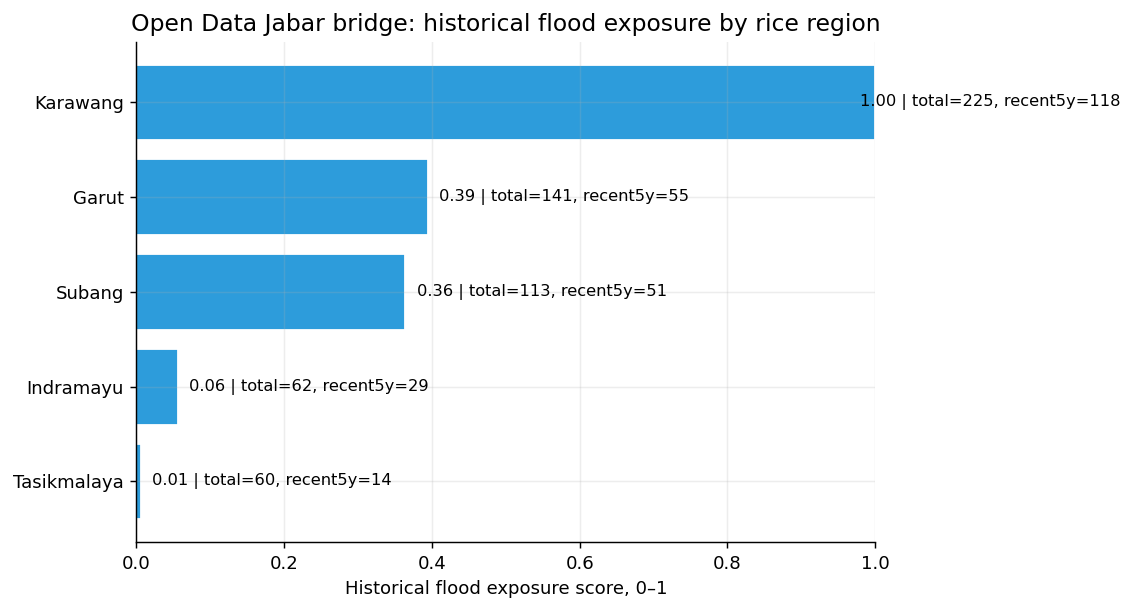

In [10]:
# External regional flood-exposure enrichment using the manually filtered Open Data Jabar CSV.
# Required file:
#   data/external/jabar_flood_events_by_kabupaten_kota.csv
#
# This CSV should contain the 5 rice-regions extracted from Open Data Jabar:
# GARUT, INDRAMAYU, KARAWANG, SUBANG, TASIKMALAYA for 2012–2025.
# It is a regional exposure bridge only. It is NOT used to train the primary FloodProbability model.

RICE_REGIONS = ['GARUT', 'INDRAMAYU', 'KARAWANG', 'SUBANG', 'TASIKMALAYA']
JABAR_FLOOD_SOURCE_URL = 'https://opendata.jabarprov.go.id/id/dataset/jumlah-kejadian-bencana-banjir-berdasarkan-kabupatenkota-di-jawa-barat'
JABAR_FLOOD_FILE = DATA_EXTERNAL / 'jabar_flood_events_by_kabupaten_kota.csv'

if not JABAR_FLOOD_FILE.exists():
    raise FileNotFoundError(
        'Missing external bridge file. Put the 5-region Open Data Jabar CSV at: '
        f'{JABAR_FLOOD_FILE}. Expected columns: nama_provinsi, nama_kabupaten_kota, '
        'jumlah_banjir, satuan, tahun.'
    )

def normalize_region_key(x):
    x = str(x).upper().strip()
    x = re.sub(r'^(KABUPATEN|KOTA)\s+', '', x)
    x = re.sub(r'\s+', ' ', x)
    return x

def display_region_from_key(x):
    return str(x).strip().title()

jabar_flood_events = pd.read_csv(JABAR_FLOOD_FILE)
jabar_source_used = JABAR_FLOOD_FILE.name

# Standardize columns.
jabar_flood_events.columns = [str(c).strip().lower() for c in jabar_flood_events.columns]
required_cols = {'nama_kabupaten_kota', 'jumlah_banjir', 'tahun'}
missing_cols = required_cols - set(jabar_flood_events.columns)
if missing_cols:
    raise ValueError(f'Jabar flood event file missing required columns: {missing_cols}. Columns found: {jabar_flood_events.columns.tolist()}')

jabar_flood_events['region_key'] = jabar_flood_events['nama_kabupaten_kota'].map(normalize_region_key)
jabar_flood_events['region'] = jabar_flood_events['region_key'].map(display_region_from_key)
jabar_flood_events['jumlah_banjir'] = pd.to_numeric(jabar_flood_events['jumlah_banjir'], errors='coerce').fillna(0)
jabar_flood_events['tahun'] = pd.to_numeric(jabar_flood_events['tahun'], errors='coerce').astype('Int64')

# Keep only the rice-supply-chain regions. The provided CSV may already be filtered; this guard keeps the notebook robust.
rice_region_events = jabar_flood_events[jabar_flood_events['region_key'].isin(RICE_REGIONS)].copy()
rice_region_events = rice_region_events.sort_values(['tahun', 'region_key']).reset_index(drop=True)

# Data-quality checks for the intended 5-region × 2012–2025 bridge.
region_coverage = rice_region_events.groupby('region_key')['tahun'].nunique().reindex(RICE_REGIONS, fill_value=0)
expected_min_rows = len(RICE_REGIONS) * 10  # allow a small tolerance if the source changes, but flag major issues
if len(rice_region_events) < expected_min_rows:
    raise ValueError(
        f'External bridge has too few rows after filtering rice regions: {len(rice_region_events)}. '
        'Expected about 70 rows for 5 regions × 2012–2025. Check the CSV content.'
    )

# Save the exact external rows used by the project.
jabar_flood_events.to_csv(DATA_EXTERNAL / 'jabar_flood_events_used_in_project.csv', index=False)
rice_region_events.to_csv(OUTPUT_DIR / '01b_jabar_flood_events_rice_regions.csv', index=False)

# Build compact region-level historical flood exposure features.
max_year = int(rice_region_events['tahun'].dropna().max())
recent_start = max_year - 4
rice_region_events['is_recent_window'] = rice_region_events['tahun'].ge(recent_start)

exposure = (
    rice_region_events.groupby(['region_key', 'region'], dropna=False)
    .agg(
        flood_events_total=('jumlah_banjir', 'sum'),
        flood_events_mean_annual=('jumlah_banjir', 'mean'),
        flood_events_recent_5y=('jumlah_banjir', lambda s: s[rice_region_events.loc[s.index, 'is_recent_window']].sum()),
        flood_events_max_yearly=('jumlah_banjir', 'max'),
        years_observed=('tahun', 'nunique'),
        latest_year=('tahun', 'max')
    )
    .reset_index()
)
exposure['flood_events_total_2012_2025'] = exposure['flood_events_total']

# Trend is a compact historical-exposure descriptor, not a causal estimate.
trends = []
for region_key, g in rice_region_events.dropna(subset=['tahun']).groupby('region_key'):
    if g['tahun'].nunique() >= 2:
        slope = np.polyfit(g['tahun'].astype(float), g['jumlah_banjir'].astype(float), 1)[0]
    else:
        slope = 0.0
    trends.append({'region_key': region_key, 'flood_events_trend_slope': slope})
trends = pd.DataFrame(trends)
exposure = exposure.merge(trends, on='region_key', how='left')

# Ensure all rice regions appear and keep both a display label (region) and a stable join key (region_key).
all_regions = pd.DataFrame({'region_key': RICE_REGIONS})
all_regions['region'] = all_regions['region_key'].map(display_region_from_key)
exposure = all_regions.merge(exposure.drop(columns=['region'], errors='ignore'), on='region_key', how='left')
for c in ['flood_events_total','flood_events_total_2012_2025','flood_events_mean_annual','flood_events_recent_5y','flood_events_max_yearly','flood_events_trend_slope']:
    exposure[c] = pd.to_numeric(exposure[c], errors='coerce').fillna(0)
exposure['years_observed'] = pd.to_numeric(exposure['years_observed'], errors='coerce').fillna(0).astype(int)
exposure['latest_year'] = pd.to_numeric(exposure['latest_year'], errors='coerce')
exposure['external_data_coverage'] = np.where(exposure['years_observed'].ge(10), 'multi-year', np.where(exposure['years_observed'].gt(0), 'partial', 'missing'))

# Normalize compact exposure score. This is a regional bridge; it must remain a small modifier downstream.
def norm(s):
    s = pd.to_numeric(s, errors='coerce').fillna(0)
    if s.max() == s.min():
        return pd.Series(0.0, index=s.index)
    return (s - s.min()) / (s.max() - s.min())

coverage_weight = exposure['external_data_coverage'].map({'multi-year': 1.0, 'partial': 0.35, 'missing': 0.0}).fillna(0.0)
base_score = (
    0.45 * norm(exposure['flood_events_total']) +
    0.35 * norm(exposure['flood_events_recent_5y']) +
    0.20 * norm(exposure['flood_events_max_yearly'])
)
exposure['historical_flood_exposure_score'] = (base_score * coverage_weight).clip(0, 1)
exposure['historical_flood_exposure_level'] = pd.cut(
    exposure['historical_flood_exposure_score'],
    bins=[-np.inf, 0.33, 0.66, np.inf],
    labels=['Low', 'Medium', 'High']
).astype(str)
exposure['source_dataset'] = 'Open Data Jabar - jumlah kejadian bencana banjir berdasarkan kabupaten/kota'
exposure['source_url'] = JABAR_FLOOD_SOURCE_URL
exposure['source_file_used'] = jabar_source_used
exposure['methodological_role'] = 'regional exposure bridge only; not used to train primary FloodProbability model'

# Final column order: region for display, region_key for safe joins.
front_cols = [
    'region', 'region_key', 'flood_events_total', 'flood_events_total_2012_2025',
    'flood_events_mean_annual', 'flood_events_recent_5y', 'flood_events_max_yearly',
    'flood_events_trend_slope', 'years_observed', 'latest_year',
    'historical_flood_exposure_score', 'historical_flood_exposure_level',
    'external_data_coverage', 'source_dataset', 'source_url', 'source_file_used', 'methodological_role'
]
exposure = exposure[[c for c in front_cols if c in exposure.columns] + [c for c in exposure.columns if c not in front_cols]]

# Save both output and reusable external summary.
exposure.to_csv(OUTPUT_DIR / '01b_jabar_flood_exposure_by_region.csv', index=False)
exposure.to_csv(DATA_EXTERNAL / 'jabar_flood_exposure_by_region_for_project.csv', index=False)

print('Jabar source used:', jabar_source_used)
print('Rows in external file:', len(jabar_flood_events))
print('Rows after filtering 5 rice regions:', len(rice_region_events))
print('Observed years by region:')
display(region_coverage.reset_index().rename(columns={'index': 'region_key', 'tahun': 'years_observed'}))
display(exposure.sort_values('historical_flood_exposure_score', ascending=False))

# Visual: regional historical flood exposure for rice regions.
fig, ax = plt.subplots(figsize=(8.8, 4.8))
plot_exp = exposure.sort_values('historical_flood_exposure_score', ascending=True)
bars = ax.barh(plot_exp['region'], plot_exp['historical_flood_exposure_score'], color=COLORS['teal'], edgecolor='white')
ax.set_xlim(0, 1)
ax.set_xlabel('Historical flood exposure score, 0–1')
ax.set_title('Open Data Jabar bridge: historical flood exposure by rice region')
for b, score, total, recent in zip(bars, plot_exp['historical_flood_exposure_score'], plot_exp['flood_events_total'], plot_exp['flood_events_recent_5y']):
    ax.text(min(score + 0.015, 0.98), b.get_y() + b.get_height()/2, f'{score:.2f} | total={total:.0f}, recent5y={recent:.0f}', va='center', fontsize=9)
savefig('01b_jabar_flood_exposure_by_region.png')
plt.show()